# Kinetic and canonic momentum comparison with or without Coulomb gauge

### Simulation parameters

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 5.0
L_fm = L
N = 1024
tau_fm = 0.3
DTS = 8

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.3
g2mu = 1.5

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_fm / a * DTS)
nplus = maxt//DTS

g = 2         		
mu = g2mu / g**2

ns = 1      

nevents = 1
# quark = 'jet' # 'jet' or 'static'            
quark = 'static'

# coulomb_gauge_mode = 'every_step' # 'none' or 'every_step' or 'initial'
coulomb_gauge_mode = 'initial'
# coulomb_gauge_mode = 'none'
alpha = 5

# Condition 1: 2*pi/L < m  (m ir regulator)
cond1_lhs = 2 * np.pi / L * hbarc
cond1 = cond1_lhs < ir
print(f"2π/L = {cond1_lhs:.4f} < m = {ir} {'passed' if cond1 else 'failed'}")

# Condition 2: m / g2mu < 1  (dense glasma)
cond2_lhs = ir / g2mu
cond2 = cond2_lhs < 1
print(f"m/g2mu = {cond2_lhs:.4f} < 1 {'passed' if cond2 else 'failed'}")

# Condition 3: g2mu * a < 1  (fine lattice)
cond3_lhs = g2mu * a / hbarc
cond3 = cond3_lhs < 1
print(f"g2mua = {cond3_lhs:.4f} < 1 {'passed' if cond3 else 'failed'}")

print(f"g2muL = {g2mu * L / hbarc :.4f}")

2π/L = 0.2480 < m = 0.3 passed
m/g2mu = 0.2000 < 1 passed
g2mua = 0.0371 < 1 passed
g2muL = 38.0082


In [1]:
import numpy as np

hbarc = 0.197326 # [GeV * fm]

# Parameters
g2mu = 1.5       # [GeV]
g2muL = 7.6       # (dimensionless)
N = 256          
m = 0.3          # [GeV]

# Derived parameters
L = g2muL / g2mu                    # L = g2muL / g2mu [GeV^-1]
L_fm = L * hbarc                    # [fm]
a = L_fm / N                        # lattice spacing [fm]
g2mua = g2mu * L / N           
E0 = N / L_fm * hbarc       

# Condition 1: 2*pi/L < m  (m ir regulator)
cond1_lhs = 2 * np.pi / L
cond1 = cond1_lhs < m
print(f"2π/L = {cond1_lhs:.4f} < m = {m} {'passed' if cond1 else 'failed'}")

# Condition 2: m / g2mu < 1  (dense glasma)
cond2_lhs = m / g2mu
cond2 = cond2_lhs < 1
print(f"m/g2mu = {cond2_lhs:.4f} < 1 {'passed' if cond2 else 'failed'}")

# Condition 3: g2mu * a < 1  (fine lattice)
cond3_lhs = g2mua
cond3 = cond3_lhs < 1
print(f"g2mua = {cond3_lhs:.4f} < 1 {'passed' if cond3 else 'failed'}")

2π/L = 1.2401 < m = 0.3 failed
m/g2mu = 0.2000 < 1 passed
g2mua = 0.0297 < 1 passed


In [ ]:
# Glasma
su_group = 'su3'
g = 2
ns = 50
uv = 1000.0 # [GeV]
# DTS = 8
DTS = 16
# g2mut = 3 
g2mut = 1 
nevents = 1

# Coulomb gauge fixing
# alpha = 0.001
coulomb_gauge_mode = 'initial'

# Derived paramaters
tau_fm = g2mut / g2mu * hbarc
ir = m
mu = g2mu / (g**2)

quark = 'jet'

### Enviroment variables

In [2]:
import os

# os.environ["MY_NUMBA_TARGET"] = "numba"
# import warnings
# from numba.core.errors import NumbaPerformanceWarning
# warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

# Comment this, I need it for JYU GPUs to choose a specific GPU to run on
os.environ["CUDA_VISIBLE_DEVICES"]="5"
os.environ["MY_NUMBA_TARGET"] = "cuda"

os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Qhat module
if quark=='jet':
    import curraun.qhat_qeik as qeik
    import curraun.qhat_original as qhat
    # import curraun.qhat_qeik_old as qeik
elif quark=='static':
    import curraun.kappa_qeik as qeik
    import curraun.kappa as qhat

# import curraun.coulomb as coulomb
import curraun.coulomb_adaptive as coulomb
coulomb.DEBUG = False

from tqdm import tqdm

Using CUDA
Using SU(3)
Using double precision


In [3]:
def simulate_qhat(ev, coulomb_gauge_mode='none'): 
    """
    Run qhat simulation with optional Coulomb gauge fixing.
    
    Parameters:
    -----------
    ev : int
        Event number for progress display
    coulomb_gauge_mode : str
        'none' - no Coulomb gauge fixing
        'initial' - apply Coulomb gauge only at initial time (tint=tstart, when a0 is computed)
        'every_step' - apply Coulomb gauge at every timestep
    """
    # Derived parameters
    a = L_fm / N
    E0 = N / L_fm * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_fm / a * DTS)

    # Initialize Glasma fields
    mv.set_seed(314)
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Qhat module
    qeik_tforce = qeik.KineticCanonicCheck(s)  
    # tau = []
    dpcan_sq, dpkin_sq, da_sq = [], [], []
    da_transp_sq, dpcanda, dpcanda_transp = [], [], []
    intfa, da = [], []

    qhat_tforce = qhat.TransportedForce(s)
    mom_broad =  []

    # Create CUDA stream for asynchronous execution
    stream = None
    if use_cuda:
        stream = cuda.stream()
        s.copy_to_device()
        qeik_tforce.copy_to_device()
        qhat_tforce.copy_to_device()

    # Determine gauge label for progress bar
    gauge_labels = {
        'none': 'no Coulomb',
        'initial': 'Coulomb at t=1',
        'every_step': 'Coulomb every step'
    }
    gauge_label = gauge_labels.get(coulomb_gauge_mode, coulomb_gauge_mode)
    
    # For 'initial' mode, we apply Coulomb gauge at tint=tstart (when a0 is computed)
    # This is when s.t = 1.0, which happens at loop iteration t = DTS
    tstart = DTS  # This is when tint == tstart in qeik_tforce.compute()
    
    with tqdm(total=maxt, desc=f"Event {ev+1} ({gauge_label})") as pbar:
        for t in range(maxt):
            # Apply Coulomb gauge transformation based on mode
            # For 'initial' mode, apply at t=DTS (when s.t=1.0 and a0 will be computed)
            apply_coulomb = (
                (coulomb_gauge_mode == 'every_step') or 
                (coulomb_gauge_mode == 'initial' and t == tstart)
            )
            
            if apply_coulomb:
                # Create Coulomb gauge transformation object
                # c = coulomb.CoulombGaugeTransf(s, alpha=alpha)
                c = coulomb.CoulombGaugeTransf(s)
                
                # Copy c to device if using CUDA (s is already on device)
                if use_cuda:
                    c.copy_to_device()
                
                # Perform gauge fixing entirely on GPU (or CPU if use_cuda=False)
                coulomb.gauge_fix(c, qeik_tforce=qeik_tforce)
                
                # No need to copy back - everything stays on device
            
            qeik_tforce.compute(stream)
            qhat_tforce.compute(stream)
            
            if t % DTS == 0:
                # Synchronize stream before copying to host
                if use_cuda:
                    stream.synchronize()
                    qeik_tforce.copy_to_host()
                    qhat_tforce.copy_mean_to_host()

                # Units GeV^2
                dpcan_sq.append(qeik_tforce.dpcan_sq_mean * E0 ** 2)
                dpkin_sq.append(qeik_tforce.dpkin_sq_mean * E0 ** 2)
                da_sq.append(qeik_tforce.da_sq_mean * E0 ** 2)
                da_transp_sq.append(qeik_tforce.da_transp_sq_mean * E0 ** 2)
                dpcanda.append(qeik_tforce.dpcanda_mean * E0 ** 2)
                dpcanda_transp.append(qeik_tforce.dpcanda_transp_mean * E0 ** 2)
                # tau.append(t*E0/DTS) # GeV^-1

                mom_broad.append(qhat_tforce.p_perp_mean * E0 ** 2)

                # No units
                intfa_sim = qeik_tforce.intfa.copy()
                intfa.append(intfa_sim[:, :, :])
                da_sim = qeik_tforce.da.copy()
                da.append(da_sim[:, :, :])

                if use_cuda:
                    qeik_tforce.copy_to_device()
                    qhat_tforce.copy_mean_to_device()
            
            # Evolve Glasma fields
            core.evolve_leapfrog(s, stream)

            pbar.update(1)
    
    if use_cuda:
        cuda.current_context().deallocations.clear()

    # units_tau = g2mu / hbarc
    units_tau = 1 / hbarc
    tau = np.linspace(0, tau_fm, num=(int(tau_fm / a)+1)) * units_tau

    return np.array(tau), dpcan_sq, dpkin_sq, da_sq, da_transp_sq, dpcanda, dpcanda_transp, np.array(intfa), np.array(da), mom_broad

In [4]:
# Run simulations without Coulomb gauge
print("Running simulations WITHOUT Coulomb gauge transformation")

collect_dpcan_sq_no_coulomb, collect_dpkin_sq_no_coulomb = [], []
collect_da_sq_no_coulomb, collect_da_transp_sq_no_coulomb = [], []
collect_dpcanda_no_coulomb, collect_dpcanda_transp_no_coulomb = [], []
collect_mom_broad_no_coulomb = []

for ev in range(nevents): 
    tau, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_no_coulomb, da_no_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode='none')

    collect_dpcan_sq_no_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_no_coulomb.append(dpkin_sq_ev)
    collect_da_sq_no_coulomb.append(da_sq_ev)
    collect_da_transp_sq_no_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_no_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_no_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_no_coulomb.append(mom_broad_ev)

dpcan_sq_no_coulomb = np.mean(collect_dpcan_sq_no_coulomb, axis=0)
dpkin_sq_no_coulomb = np.mean(collect_dpkin_sq_no_coulomb, axis=0)
da_sq_no_coulomb = np.mean(collect_da_sq_no_coulomb, axis=0)
da_transp_sq_no_coulomb = np.mean(collect_da_transp_sq_no_coulomb, axis=0)
dpcanda_no_coulomb = np.mean(collect_dpcanda_no_coulomb, axis=0)
dpcanda_transp_no_coulomb = np.mean(collect_dpcanda_transp_no_coulomb, axis=0)  
mom_broad_no_coulomb = np.mean(collect_mom_broad_no_coulomb, axis=0)

Running simulations WITHOUT Coulomb gauge transformation


Event 1 (no Coulomb): 100%|██████████| 491/491 [1:53:36<00:00, 13.88s/it]


In [7]:
# Run simulations with Coulomb gauge (mode from cell-2)
print(f"Running simulations WITH Coulomb gauge transformation (mode: {coulomb_gauge_mode})")

collect_dpcan_sq_coulomb, collect_dpkin_sq_coulomb = [], []
collect_da_sq_coulomb, collect_da_transp_sq_coulomb = [], []
collect_dpcanda_coulomb, collect_dpcanda_transp_coulomb = [], []
collect_mom_broad_coulomb = []

for ev in range(nevents): 
    tau, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_coulomb, da_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode)

    collect_dpcan_sq_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_coulomb.append(dpkin_sq_ev)
    collect_da_sq_coulomb.append(da_sq_ev)
    collect_da_transp_sq_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_coulomb.append(mom_broad_ev)

dpcan_sq_coulomb = np.mean(collect_dpcan_sq_coulomb, axis=0)
dpkin_sq_coulomb = np.mean(collect_dpkin_sq_coulomb, axis=0)
da_sq_coulomb = np.mean(collect_da_sq_coulomb, axis=0)
da_transp_sq_coulomb = np.mean(collect_da_transp_sq_coulomb, axis=0)
dpcanda_coulomb = np.mean(collect_dpcanda_coulomb, axis=0)
dpcanda_transp_coulomb = np.mean(collect_dpcanda_transp_coulomb, axis=0)  
mom_broad_coulomb = np.mean(collect_mom_broad_coulomb, axis=0)

Running simulations WITH Coulomb gauge transformation (mode: initial)


Event 1 (Coulomb at t=1):   0%|          | 1/491 [00:04<32:53,  4.03s/it]

Coulomb gauge condition reached in 74 iterations with theta=9.65e-13


Event 1 (Coulomb at t=1): 100%|██████████| 491/491 [1:42:46<00:00, 12.56s/it]


In [5]:
import pickle, os

ntraj_save = 40  # only save first 20 trajectories for per-trajectory data

results = {
    # Simulation parameters
    'tau': tau,
    'g2mu': g2mu,
    'E0': E0,
    'N': N,
    'quark': quark,
    'coulomb_gauge_mode': coulomb_gauge_mode,
    # No Coulomb gauge results (event-averaged)
    'dpcan_sq_no_coulomb': dpcan_sq_no_coulomb,
    'dpkin_sq_no_coulomb': dpkin_sq_no_coulomb,
    'da_sq_no_coulomb': da_sq_no_coulomb,
    'da_transp_sq_no_coulomb': da_transp_sq_no_coulomb,
    'dpcanda_no_coulomb': dpcanda_no_coulomb,
    'dpcanda_transp_no_coulomb': dpcanda_transp_no_coulomb,
    'mom_broad_no_coulomb': mom_broad_no_coulomb,
    # Coulomb gauge results (event-averaged)
    # 'dpcan_sq_coulomb': dpcan_sq_coulomb,
    # 'dpkin_sq_coulomb': dpkin_sq_coulomb,
    # 'da_sq_coulomb': da_sq_coulomb,
    # 'da_transp_sq_coulomb': da_transp_sq_coulomb,
    # 'dpcanda_coulomb': dpcanda_coulomb,
    # 'dpcanda_transp_coulomb': dpcanda_transp_coulomb,
    # 'mom_broad_coulomb': mom_broad_coulomb,
    # Per-trajectory group element data (last event, first ntraj_save trajectories)
    'intfa_no_coulomb': intfa_no_coulomb[:, :ntraj_save],
    'da_no_coulomb': da_no_coulomb[:, :ntraj_save],
    # 'intfa_coulomb': intfa_coulomb[:, :ntraj_save],
    # 'da_coulomb': da_coulomb[:, :ntraj_save],
}

fname = f'qhat_coulomb_results_{quark}_n_{N}_{coulomb_gauge_mode}_dimensionless_final.pickle'
# fname = f'qhat_results_{quark}_n_{N}_{coulomb_gauge_mode}.pickle'
with open(fname, 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
    f.flush()
    os.fsync(f.fileno())
print(f"Results saved to {fname} ({os.path.getsize(fname) / 1024**2:.1f} MB)")

Results saved to qhat_coulomb_results_static_n_1024_initial_dimensionless_final.pickle (2.1 MB)


In [9]:
quark = 'jet'
# quark = 'static'
N = 1024
coulomb_gauge_mode = 'initial'

In [10]:
import pickle

fname = f'qhat_coulomb_results_{quark}_n_{N}_{coulomb_gauge_mode}_dimensionless_final.pickle'
with open(fname, 'rb') as f:
    results = pickle.load(f)

# Unpack simulation parameters
tau = results['tau']
g2mu = results['g2mu']
E0 = results['E0']
N = results['N']
quark = results['quark']
coulomb_gauge_mode = results['coulomb_gauge_mode']

# Unpack no-Coulomb gauge results
dpcan_sq_no_coulomb = results['dpcan_sq_no_coulomb']
dpkin_sq_no_coulomb = results['dpkin_sq_no_coulomb']
da_sq_no_coulomb = results['da_sq_no_coulomb']
da_transp_sq_no_coulomb = results['da_transp_sq_no_coulomb']
dpcanda_no_coulomb = results['dpcanda_no_coulomb']
dpcanda_transp_no_coulomb = results['dpcanda_transp_no_coulomb']
mom_broad_no_coulomb = results['mom_broad_no_coulomb']

if quark == 'jet':
    # Coulomb gauge results
    dpcan_sq_coulomb = results['dpcan_sq_coulomb']
    dpkin_sq_coulomb = results['dpkin_sq_coulomb']
    da_sq_coulomb = results['da_sq_coulomb']
    da_transp_sq_coulomb = results['da_transp_sq_coulomb']
    dpcanda_coulomb = results['dpcanda_coulomb']
    dpcanda_transp_coulomb = results['dpcanda_transp_coulomb']
    mom_broad_coulomb = results['mom_broad_coulomb']

    # Per-trajectory group element data
    intfa_no_coulomb = results['intfa_no_coulomb']
    da_no_coulomb = results['da_no_coulomb']
    intfa_coulomb = results['intfa_coulomb']
    da_coulomb = results['da_coulomb']

print(f"Loaded results from {fname}")


Loaded results from qhat_coulomb_results_jet_n_1024_initial_dimensionless_final.pickle


---
### Comparison kinetic and canonic momentum broadening without and with Coulomb gauge

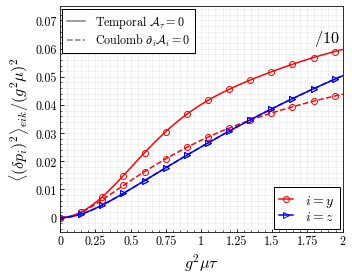

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "text.latex.preamble": r"\usepackage{txfonts}"
# })
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

markers = ['o', 's']  # circle for y, square for z

# Division factors for each component
factor_y_no_coulomb = 10
factor_y_coulomb = 1
factor_z_no_coulomb = 1
factor_z_coulomb = 1

Nc = 3

# Plot canonical momentum broadening
# Without Coulomb (temporal) - blue solid line
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, 1] / factor_y_no_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, 2] / factor_z_no_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=6, markevery=4, markerfacecolor='none')

if quark == 'jet':
    # With Coulomb - red dashed line
    ax.plot(g2mu * tau, dpcan_sq_coulomb[:, 1] / factor_y_coulomb / g2mu**2 / Nc, linewidth=1.5, 
            color='red', linestyle='--', marker='o', markersize=6, markevery=4, markerfacecolor='none')
    ax.plot(g2mu * tau, dpcan_sq_coulomb[:, 2] / factor_z_coulomb / g2mu**2 / Nc, linewidth=1.5, 
            color='blue', linestyle='--', marker='>', markersize=6, markevery=4, markerfacecolor='none')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.005, 0.075])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

# Set tick spacing (adjust independently for each axis)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.01))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta p_i)^2\rangle_{eik}/ (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

# Text label (adjust coordinates as needed)
ax.text(0.9, 0.84, r'$/10$', transform=ax.transAxes, fontsize=16)

# Legend 1: y and z components (different markers)
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=14, loc='lower right', handlelength=1.0, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

# Legend 2: Coulomb vs temporal (different colors + linestyles)
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\mathrm{Coulomb}\,\,\partial_{i}\mathcal{A}_{i}=0$'),
]
ax.add_artist(legend1)
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

plt.tight_layout()
# plt.savefig(f'final_pcan_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}_v2.pdf', facecolor='w')
plt.show()

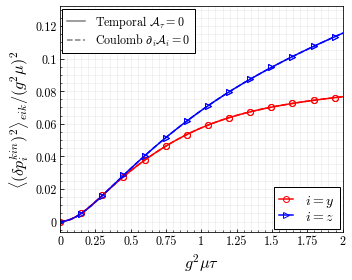

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "text.latex.preamble": r"\usepackage{txfonts}"
# })
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

markers = ['o', 's']  # circle for y, square for z

# Division factors for each component
factor_y_no_coulomb = 1
factor_y_coulomb = 1
factor_z_no_coulomb = 1
factor_z_coulomb = 1

# Plot kinetic momentum broadening
# Without Coulomb (temporal) - solid line
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, 1] / factor_y_no_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, 2] / factor_z_no_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=6, markevery=4, markerfacecolor='none')

# With Coulomb - dashed line
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, 1] / factor_y_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, 2] / factor_z_coulomb / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=6, markevery=4, markerfacecolor='none')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
# ax.set_ylim([-0.01, 0.31])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

# Set tick spacing (adjust independently for each axis)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(0.06))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta p_i^{kin})^2\rangle_{eik}/ (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

# Text label (adjust coordinates as needed)
# ax.text(0.91, 0.85, r'$/10$', transform=ax.transAxes, fontsize=14)

# Legend 1: y and z components (different markers)
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=14, loc='lower right', handlelength=1.0, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

# Legend 2: Coulomb vs temporal (different colors + linestyles)
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$'),
]
ax.add_artist(legend1)
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

plt.tight_layout()
plt.savefig(f'final_pkin_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}_thin_dash.pdf', facecolor='w')
plt.show()


---
## Combined comparison plot

In [8]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker

# plt.rcParams['font.family'] = 'DejaVu Serif'
# plt.rcParams['font.serif'] = ['DejaVu Serif']
# plt.rcParams['mathtext.fontset'] = 'cm'

# fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# labels = ['x', 'y', 'z']
# directions = [1, 2]  # y and z
# direction_labels = ['y', 'z']

# for idx, i in enumerate(directions):
#     ax = axes[idx]
    
#     # Plot both pcan and pkin for without Coulomb
#     line1, = ax.plot(tau, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
#                      color='blue', label=rf'$p^{{\mathrm{{can}}}}$ (no Coulomb)')
#     line2, = ax.plot(tau, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
#                      color='green', label=rf'$p^{{\mathrm{{kin}}}}$ (no Coulomb)')
    
#     # Plot both pcan and pkin for with Coulomb
#     line3, = ax.plot(tau, dpcan_sq_coulomb[:, i], linewidth=2.0, 
#                      color='blue', linestyle='--', label=rf'$p^{{\mathrm{{can}}}}$ (with Coulomb)')
#     line4, = ax.plot(tau, dpkin_sq_coulomb[:, i], linewidth=2.0, 
#                      color='green', linestyle='--', label=rf'$p^{{\mathrm{{kin}}}}$ (with Coulomb)')
    
#     ax.set_xlim([0, max(tau)])
#     ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
#     ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
#     ax.set_xlabel(r"$\tau\,\mathrm{[fm]}$", fontsize=18)
#     ax.set_ylabel(rf"$\langle (\delta p_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
#     ax.set_title(f'{direction_labels[idx]} direction', fontsize=16)
#     ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
#     ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
#     ax.minorticks_on()
#     ax.tick_params(axis='both', which='minor', direction='in')
#     ax.legend(fontsize=12, frameon=False)

# plt.tight_layout()
# # plt.savefig(f'combined_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
# plt.show()

---
# Numerical checks
Compare the time-integrated Lorentz force that contribues to the gauge field, and the relative difference containing the parallel transported gauge field

$$\int_{\tau_0}^\tau \mathrm{d}\tau^\prime \tilde{f}^A_i(\tau^\prime)=\tilde{A}_i(\tau)-A_i(\tau_0)$$

where $\tilde{f}_i(\tau)=U(\tau,\tau_0)f_i U^\dagger(\tau,\tau_0)$ rotated with the Wilson line along the eikonal jet trajectory, and similarly for $\tilde{A}_i$. The Lorentz force contains
\begin{equation*}f_i^A=f_i^{p,\mathrm{can}}-f_i^{p,\mathrm{kin}}\end{equation*}
with the relevant components 
\begin{equation*}f_y^{p,\mathrm{can}}=-\partial_yA_x= -B_z^\mathrm{can},\quad f_z^{p,\mathrm{can}}=-\dfrac{1}{\tau^2} A_\eta = E_z^\mathrm{can}\end{equation*}
along with 
\begin{equation*}f_y^{p,\mathrm{kin}}=\dfrac{1}{\tau} P^y+F_{xy}= E_y^\mathrm{kin}-B_z^\mathrm{kin},\quad f_z^{p,\mathrm{kin}}=P^\eta+\dfrac{1}{\tau} D_xA_\eta=E_z^\mathrm{kin}+B_y^\mathrm{kin}\end{equation*}

In [7]:
import curraun.su3 as _su3

_gens = [np.array(s).reshape(3, 3) for s in [_su3.s1, _su3.s2, _su3.s3, _su3.s4, _su3.s5, _su3.s6, _su3.s7, _su3.s8]]

def _get_algebra_factors_cpu(g):
    m = np.array(g).reshape(3, 3)
    return tuple(np.trace(s @ m).imag for s in _gens)

_su3.get_algebra_factors_from_group_element_approximate = _get_algebra_factors_cpu

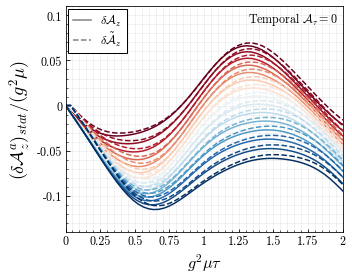

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

ntraj = 15
cmap_rb = plt.cm.get_cmap('RdBu', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 2  # z direction
# na = 5  # algebra factor index (0-7 for SU(3)) eik
na = 3  # algebra factor index (0-7 for SU(3)) stat

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_no_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_no_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.14, 0.11])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
# ax.set_ylabel(r"$(\delta \mathcal{A}^a_z)_{eik}/(g^2\mu)$", fontsize=16)
ax.set_ylabel(r"$(\delta \mathcal{A}^a_z)_{stat}/(g^2\mu)$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_z$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_z$'),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.66, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='white', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_intfa_deltaa_z_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()


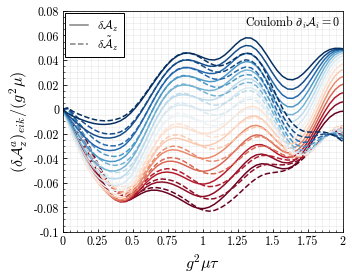

In [70]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

ntraj = 15
cmap_rb = plt.cm.get_cmap('RdBu', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 2  # z direction
# na = 3  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.1, 0.08])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(0.08))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$(\delta \mathcal{A}^a_z)_{eik}/(g^2\mu)$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_z$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_z$'),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.65, 0.93, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_intfa_deltaa_z_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()


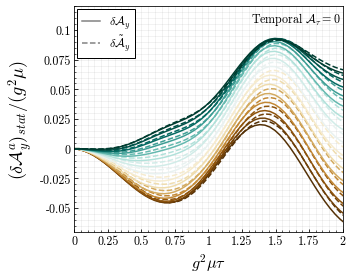

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

ntraj = 15
cmap_rb = plt.cm.get_cmap('BrBG', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 1  # y direction
# na = 7  # algebra factor index (0-7 for SU(3)) eik
na = 0  # algebra factor index (0-7 for SU(3)) stat

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_no_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_no_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.07, 0.12])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(0.8))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
# ax.set_ylabel(r"$(\delta \mathcal{A}^a_y)_{eik}/(g^2\mu)$", fontsize=16)
ax.set_ylabel(r"$(\delta \mathcal{A}^a_y)_{stat}/(g^2\mu)$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_y$'),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.66, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_intfa_deltaa_y_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()


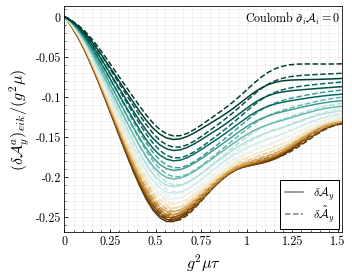

In [99]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

ntraj = 15
cmap_rb = plt.cm.get_cmap('BrBG', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 1  # y direction
# na = 0  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

ax.set_xlim([0, max(tau)])
# ax.set_xlim([0, 0.3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

# ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$(\delta \mathcal{A}^a_y)_{eik}/(g^2\mu)$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_y$'),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='lower right', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.65, 0.93, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_intfa_deltaa_y_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()


---
### $\delta A$ vs $\delta\tilde{A}$ comparison

In [5]:
Nc = 3

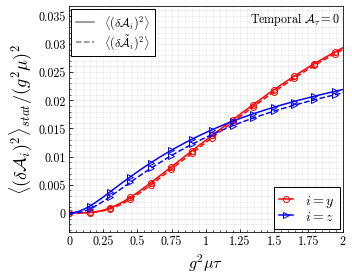

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

# Without Coulomb gauge
i = 1  # y direction
# factor = 10 # eik
factor = 1 
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2 / factor / Nc, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2 / factor / Nc, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=6, markevery=4, markerfacecolor='none')

i = 2  # z direction
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=6, markevery=4, markerfacecolor='none')

ax.set_xlim([0, 2])
# ax.set_xlim([0, max(g2mu * tau)])
# ax.set_ylim([-0.01, 0.095]) # eik
ax.set_ylim([-0.01/3, 0.11/3]) # stat

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(0.015))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
# ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle_{stat} / (g^2\mu)^2$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

# Legend 1: y and z components
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=14, loc='lower right', handlelength=1.0, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.66, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))
# ax.text(0.92, 0.84, r'$/10$', transform=ax.transAxes, fontsize=14) # eik
# ax.text(0.92, 0.64, r'$/10$', transform=ax.transAxes, fontsize=14) # eik

# Legend 2: A vs A tilde
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\langle (\delta \mathcal{A}_i)^2\rangle$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\langle (\delta \tilde{\mathcal{A}}_i)^2\rangle$'),
]
ax.add_artist(legend1)
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

plt.tight_layout()
plt.savefig(f'final_a_no_coulomb_{quark}_n_{N}_v2.pdf', facecolor='w')
plt.show()


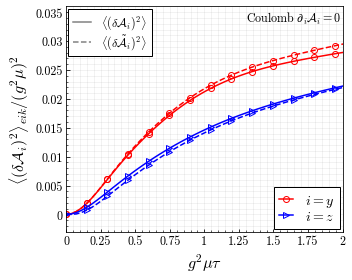

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fig, ax = plt.subplots(figsize=(5, 4))

# With Coulomb gauge
i = 1  # y direction
ax.plot(g2mu * tau, da_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=6, markevery=4, markerfacecolor='none')

i = 2  # z direction
ax.plot(g2mu * tau, da_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=6, markevery=4, markerfacecolor='none')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.003, 0.036])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

# Legend 1: y and z components
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=6, markerfacecolor='none', linestyle='-', lw=1.5, label=r'$i=z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=14, loc='lower right', handlelength=1.0, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")

ax.text(0.65, 0.93, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

# Legend 2: A vs A tilde
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\langle (\delta \mathcal{A}_i)^2\rangle$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\langle (\delta \tilde{\mathcal{A}}_i)^2\rangle$'),
]
ax.add_artist(legend1)
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper left', handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

plt.tight_layout()
plt.savefig(f'final_a_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}_v2.pdf', facecolor='w')
plt.show()


---
### Decomposition: $\langle (\delta p^{\mathrm{kin}})^2 \rangle = \langle (\delta p^{\mathrm{can}})^2 \rangle + \langle (\delta \mathcal{A})^2 \rangle + 2\langle \delta p^{\mathrm{can}} \delta \mathcal{A} \rangle$

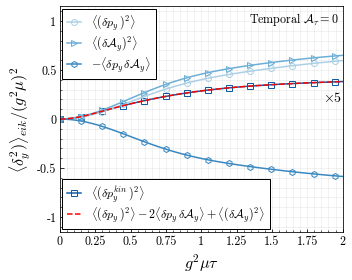

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 1  # y direction

factor = 5
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_sq_no_coulomb[:, i] + 2 * dpcanda_no_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-1.15, 1.15])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \mathcal{A}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_y \,\delta \mathcal{A}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \mathcal{A}_y\rangle + \langle (\delta \mathcal{A}_y)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.67, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))
ax.text(0.93, 0.58, r'$\times 5$', transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig(f'final_decomposition_y_no_coulomb_{quark}_n_{N}_v2.pdf', facecolor='w')
plt.show()


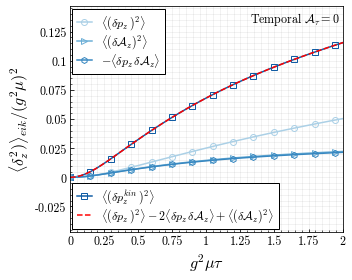

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_sq_no_coulomb[:, i] + 2 * dpcanda_no_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.14/3, 0.44/3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \mathcal{A}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_z \,\delta \mathcal{A}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \mathcal{A}_z\rangle + \langle (\delta \mathcal{A}_z)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.66, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'final_decomposition_z_no_coulomb_{quark}_n_{N}_v2.pdf', facecolor='w')
plt.show()


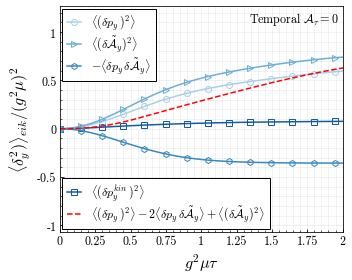

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 1  # y direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_transp_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_transp_sq_no_coulomb[:, i] + 2 * dpcanda_transp_no_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-3.2/3, 3.8/3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(1.2))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle + \langle (\delta \tilde{\mathcal{A}}_y)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.67, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'final_decomposition_y_atilde_no_coulomb_{quark}_n_{N}_v2.pdf', facecolor='w')
plt.show()

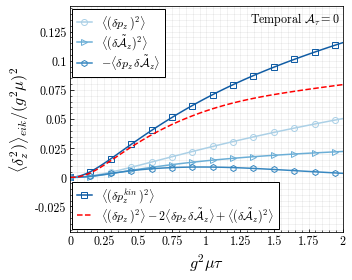

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_transp_no_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_transp_sq_no_coulomb[:, i] + 2 * dpcanda_transp_no_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.14/3, 0.44/3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle + \langle (\delta \tilde{\mathcal{A}}_z)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.66, 0.93, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_decomposition_z_atilde_no_coulomb_{quark}_n_{N}_v2.pdf', facecolor='w')
plt.show()


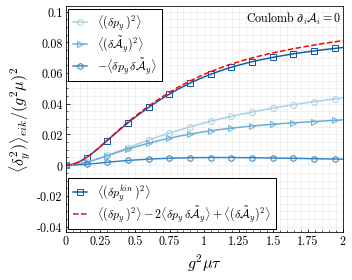

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 1  # y direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_transp_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_coulomb[:, i] + da_transp_sq_coulomb[:, i] + 2 * dpcanda_transp_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.13/3, 0.31/3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
# ax.yaxis.set_major_locator(mticker.MultipleLocator(0.08))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle + \langle (\delta \tilde{\mathcal{A}}_y)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.65, 0.93, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'final_decomposition_y_atilde_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}_v2.pdf', facecolor='w')
plt.show()


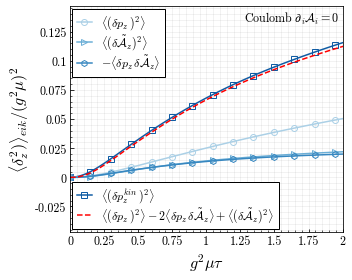

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(5, 4))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, i] / g2mu**2 * factor / Nc, linewidth=1.5, color=colors[5], marker='s', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[2], marker='o', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[3], marker='>', markersize=6, markevery=4, markerfacecolor='none')
ax.plot(g2mu * tau, dpcanda_transp_coulomb[:, i] / g2mu**2 / Nc, linewidth=1.5, color=colors[4], marker='h', markersize=6, markevery=4, markerfacecolor='none')
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_coulomb[:, i] + da_transp_sq_coulomb[:, i] + 2 * dpcanda_transp_coulomb[:, i]) / g2mu**2 * factor / Nc, 
        linewidth=1.5, color='red', linestyle='--')

ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 2])
ax.set_ylim([-0.14/3, 0.44/3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle_{eik} / (g^2\mu)^2$", fontsize=16)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=6, markerfacecolor='none', label=r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=6, markerfacecolor='none', label=r"$-\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, loc='upper left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=6, markerfacecolor='none', label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle + \langle (\delta \tilde{\mathcal{A}}_z)^2\rangle $"),
]
legend2 = ax.legend(handles=legend_elements_2, fontsize=12, loc='lower left', handlelength=1.2, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.1, labelspacing=0.1)
legend2.get_frame().set_boxstyle("square")

ax.text(0.64, 0.93, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12, bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig(f'final_decomposition_z_atilde_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}_v2.pdf', facecolor='w')
plt.show()


---